In [81]:
import pandas as pd
import numpy as np
from os import listdir


In [82]:
import sklearn

In [83]:
# Ignore warnings
import warnings; warnings.simplefilter("ignore")
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.model_selection import LeaveOneGroupOut
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline



from sklearn.metrics import precision_score, recall_score, accuracy_score, balanced_accuracy_score
from sklearn import svm
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.model_selection import cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
import numpy as np
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

#from skbold.preproc.confounds import ConfoundRegressor
from sklearn.pipeline import make_pipeline

from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold, RandomizedSearchCV
from sklearn import preprocessing
    
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score,confusion_matrix, recall_score, precision_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.impute import SimpleImputer



# Import libraries
import os
import numpy as np
import pandas as pd


from sklearn.feature_selection import RFE
from sklearn.metrics import balanced_accuracy_score

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_classif
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold, RandomizedSearchCV
from sklearn.model_selection import cross_validate, cross_val_score, cross_val_predict
from sklearn.metrics import make_scorer
from sklearn.metrics import \
    confusion_matrix, \
    accuracy_score, \
    matthews_corrcoef, \
    precision_score, \
    recall_score, \
    f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut


import pymrmr

# Set the random generator seed
seed = 42

# Matplotlib settings
plt.style.use("classic")

# Seaborn settings
sns.set()
sns.set(font_scale=1.0)
sns.set_style({"font.family":"serif", "font.serif":["Times New Roman"]})

# Show seaborn settings
sns.axes_style()

{'axes.facecolor': '#EAEAF2',
 'axes.edgecolor': 'white',
 'axes.grid': True,
 'axes.axisbelow': True,
 'axes.labelcolor': '.15',
 'figure.facecolor': 'white',
 'grid.color': 'white',
 'grid.linestyle': '-',
 'text.color': '.15',
 'xtick.color': '.15',
 'ytick.color': '.15',
 'xtick.direction': 'out',
 'ytick.direction': 'out',
 'lines.solid_capstyle': <CapStyle.round: 'round'>,
 'patch.edgecolor': 'w',
 'patch.force_edgecolor': True,
 'image.cmap': 'rocket',
 'font.family': ['serif'],
 'font.sans-serif': ['Arial',
  'DejaVu Sans',
  'Liberation Sans',
  'Bitstream Vera Sans',
  'sans-serif'],
 'xtick.bottom': False,
 'xtick.top': False,
 'ytick.left': False,
 'ytick.right': False,
 'axes.spines.left': True,
 'axes.spines.bottom': True,
 'axes.spines.right': True,
 'axes.spines.top': True}

In [84]:
# ------------------------------
# Define the classifier settings
# ------------------------------

model_params = {
    
    # General parameters
    "booster": "gbtree", 
    "silent": True, 
    "n_jobs": -1, 
    
    # Learning task parameters
    "objective": "binary:logistic",  # https://xgboost.readthedocs.io/en/latest/parameter.html
    "eval_metric": "error", 
    "seed": seed, 
    
    # Tree Booster parameters
    "n_estimators": 500, 
    "learning_rate": 0.20, 
    "gamma": 1.0, 
    "max_depth": 10, 
    "subsample": 1.0, 
    "colsample_bylevel": 1, 
    "colsample_bytree": 1.0, 
    "min_child_weight": 5
}

# ------------------------------------------
# Define the hyper-parameter tuning settings
# ------------------------------------------

param_grid = {
    "learning_rate": [0.001, 0.01, 0.1, 0.2, 0.3], 
    "gamma": [0, 0.10, 0.15, 0.25, 0.5], 
    "max_depth": [6, 8, 10, 12, 15],  
    "subsample": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0], 
    "colsample_bylevel": [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], 
    "colsample_bytree": [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], 
    "min_child_weight": [0.5, 1.0, 3.0, 5.0, 7.0, 10.0], 
    "scale_pos_weight": [1, 3, 5, 6, 7, 9]  # https://machinelearningmastery.com/xgboost-for-imbalanced-classification/
#scale_pos_weight = total_negative_examples / total_positive_examples
}

search_settings = {
    "param_distributions": param_grid, 
    "scoring": "balanced_accuracy",  # https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter
    "n_jobs": -1, 
    "n_iter": 500, 
    "verbose": 1
}

In [85]:
# ---------------------------------
# Define the classification metrics
# ---------------------------------

def sensitivity_score(y_true, y_pred):
    return recall_score(y_true, y_pred)

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

In [86]:
from sklearn.metrics import balanced_accuracy_score
from sklearn.linear_model import LinearRegression as lr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import os

# For preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import Normalizer
from sklearn.model_selection import train_test_split

# For models
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

# For evaluation
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import OneHotEncoder


In [87]:
dataset = pd.read_csv('euler_features.csv')

In [88]:
del dataset['Unnamed: 0']
del dataset['index']
del dataset['level_0']

In [89]:
del dataset['timestamp_start']
del dataset['timestamp_end']

In [90]:
dataset

,patient,record,diagnosis,X_mid_Absolute energy,X_mid_Area under the curve,X_mid_Autocorrelation,X_mid_Average power,X_mid_Centroid,X_mid_ECDF Percentile Count_0,X_mid_ECDF Percentile Count_1,...,Z_eve_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,Z_eve_SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,Z_eve_SP_Summaries_welch_rect_centroid,Z_eve_FC_LocalSimple_mean3_stderr,X_eve_app_ent,Y_eve_app_ent,Z_eve_app_ent,X_eve_rsd,Y_eve_rsd,Z_eve_rsd
0,P08,0,0,2.385522e+04,17.340800,16.0,11580.203963,0.936651,41.0,165.0,...,0.183673,0.877551,0.038350,0.556470,1.240145,1.414059,1.101619,-137.406912,247.810229,-84.170855
1,P08,1,0,2.328345e+05,239.885354,42.0,6007.081693,21.592224,775.0,3101.0,...,0.437500,0.875000,0.104311,0.664134,1.110772,1.153594,1.206691,-246.703278,-917.852063,-147.429543
2,P10,2,1,4.725678e+04,54.145724,63.0,4535.199168,6.523586,208.0,834.0,...,0.125000,0.854167,0.193282,0.768328,0.829204,1.076619,1.013430,114.967050,-107.494007,-224.427014
3,P10,3,0,1.807770e+05,129.773994,65.0,14002.863964,7.335980,258.0,1033.0,...,0.224490,0.122449,0.138058,0.682936,0.659745,0.789076,0.931019,65.528455,-348.921557,-328.457878
4,P12,4,1,4.557987e+04,24.120677,8.0,30386.579672,0.962864,30.0,120.0,...,0.860465,0.139535,0.613592,0.924430,0.938069,0.806088,0.934574,72.352631,177.627123,159.713801
5,P12,5,1,2.937881e+04,14.343478,2.0,34974.776061,0.392917,17.0,68.0,...,0.619048,0.738095,0.269981,0.758146,0.529294,0.502848,0.595768,44.882796,-1732.345347,174.352004
6,P13,6,0,1.425495e+05,166.412023,56.0,4206.240544,18.322024,678.0,2712.0,...,0.755102,0.510204,0.036816,0.527443,0.646985,0.687472,0.806980,172.224880,46.271562,73.328927
7,P13,7,0,1.526638e+04,15.338700,11.0,6131.074397,0.533629,50.0,200.0,...,0.780488,0.731707,0.220893,0.714463,0.864127,0.889067,0.751850,-108.350642,22.814158,63.237315
8,P14,8,0,2.917384e+04,22.015482,8.0,15354.652608,1.082417,38.0,152.0,...,0.448980,0.530612,0.085903,0.636002,1.382823,1.206934,1.187669,318.194246,-125.681839,133.769104
9,P15,9,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.122449,0.448980,0.171806,0.654882,0.913396,0.750667,0.753536,42.929179,1791.647415,1154.407059


In [91]:
flag = 0 
for i in range(0, 43):
    subdata = pd.read_csv('.\dataset\euler_cross\eul_'+str(i)+'_.csv')
    if len(subdata)>1:
        if flag==0:
            subdata_all = subdata.loc[1:].copy()
            flag = 1
        else:
            subdata_all = pd.concat([subdata_all, subdata.loc[1:]])



In [92]:
del subdata_all['Unnamed: 0']
del subdata_all['type_data']
del subdata_all['subrecord']

In [93]:
dataset = pd.concat([dataset, subdata_all])

In [94]:
group = dataset['patient']

In [95]:
group = dataset['patient']
patients_pandas_encoded = pd.get_dummies(group, columns=['patient'], drop_first=False)


In [96]:
dataset

,patient,record,diagnosis,X_mid_Absolute energy,X_mid_Area under the curve,X_mid_Autocorrelation,X_mid_Average power,X_mid_Centroid,X_mid_ECDF Percentile Count_0,X_mid_ECDF Percentile Count_1,...,Z_eve_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,Z_eve_SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,Z_eve_SP_Summaries_welch_rect_centroid,Z_eve_FC_LocalSimple_mean3_stderr,X_eve_app_ent,Y_eve_app_ent,Z_eve_app_ent,X_eve_rsd,Y_eve_rsd,Z_eve_rsd
0,P08,0,0,23855.220164,17.340800,16.0,11580.203963,0.936651,41.0,165.0,...,0.183673,0.877551,0.038350,0.556470,1.240145,1.414059,1.101619,-137.406912,247.810229,-84.170855
1,P08,1,0,232834.486420,239.885354,42.0,6007.081693,21.592224,775.0,3101.0,...,0.437500,0.875000,0.104311,0.664134,1.110772,1.153594,1.206691,-246.703278,-917.852063,-147.429543
2,P10,2,1,47256.775336,54.145724,63.0,4535.199168,6.523586,208.0,834.0,...,0.125000,0.854167,0.193282,0.768328,0.829204,1.076619,1.013430,114.967050,-107.494007,-224.427014
3,P10,3,0,180776.973773,129.773994,65.0,14002.863964,7.335980,258.0,1033.0,...,0.224490,0.122449,0.138058,0.682936,0.659745,0.789076,0.931019,65.528455,-348.921557,-328.457878
4,P12,4,1,45579.869508,24.120677,8.0,30386.579672,0.962864,30.0,120.0,...,0.860465,0.139535,0.613592,0.924430,0.938069,0.806088,0.934574,72.352631,177.627123,159.713801
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,P38,42,0,2758.535817,1.653038,2.0,22987.798476,0.039375,2.0,10.0,...,0.133333,0.800000,0.098175,0.662341,0.640145,0.372869,0.618174,53.749888,-244.113980,-46.387010
3,P38,42,0,36251.549716,26.396818,7.0,18035.596874,1.024986,40.0,161.0,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN
4,P38,42,0,2758.535817,1.653038,2.0,22987.798476,0.039375,2.0,10.0,...,0.127660,0.829787,0.042951,0.639221,0.495891,0.394368,0.538228,53.596463,-154.809423,-47.504810
5,P38,42,0,89778.428991,47.384176,9.0,33374.880666,1.347406,54.0,216.0,...,0.130435,0.826087,0.012272,0.358083,0.721151,0.482126,0.499161,34.958433,-70.161978,-346.662099


In [97]:
del dataset['patient']

In [98]:
dataset = dataset.fillna(dataset.mean())

In [99]:
y = dataset['diagnosis']

In [100]:
records  = dataset['record']

In [101]:
del dataset['record']

In [102]:
X = dataset.copy()

In [103]:
dataset

,diagnosis,X_mid_Absolute energy,X_mid_Area under the curve,X_mid_Autocorrelation,X_mid_Average power,X_mid_Centroid,X_mid_ECDF Percentile Count_0,X_mid_ECDF Percentile Count_1,X_mid_ECDF Percentile_0,X_mid_ECDF Percentile_1,...,Z_eve_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,Z_eve_SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,Z_eve_SP_Summaries_welch_rect_centroid,Z_eve_FC_LocalSimple_mean3_stderr,X_eve_app_ent,Y_eve_app_ent,Z_eve_app_ent,X_eve_rsd,Y_eve_rsd,Z_eve_rsd
0,0,23855.220164,17.340800,16.0,11580.203963,0.936651,41.0,165.0,-9.678244,8.129680,...,0.183673,0.877551,0.038350,0.556470,1.240145,1.414059,1.101619,-137.406912,247.810229,-84.170855
1,0,232834.486420,239.885354,42.0,6007.081693,21.592224,775.0,3101.0,-6.714967,7.409895,...,0.437500,0.875000,0.104311,0.664134,1.110772,1.153594,1.206691,-246.703278,-917.852063,-147.429543
2,1,47256.775336,54.145724,63.0,4535.199168,6.523586,208.0,834.0,0.101188,8.796706,...,0.125000,0.854167,0.193282,0.768328,0.829204,1.076619,1.013430,114.967050,-107.494007,-224.427014
3,0,180776.973773,129.773994,65.0,14002.863964,7.335980,258.0,1033.0,4.734332,16.193260,...,0.224490,0.122449,0.138058,0.682936,0.659745,0.789076,0.931019,65.528455,-348.921557,-328.457878
4,1,45579.869508,24.120677,8.0,30386.579672,0.962864,30.0,120.0,11.991434,20.029226,...,0.860465,0.139535,0.613592,0.924430,0.938069,0.806088,0.934574,72.352631,177.627123,159.713801
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,0,2758.535817,1.653038,2.0,22987.798476,0.039375,2.0,10.0,10.401367,15.110086,...,0.133333,0.800000,0.098175,0.662341,0.640145,0.372869,0.618174,53.749888,-244.113980,-46.387010
3,0,36251.549716,26.396818,7.0,18035.596874,1.024986,40.0,161.0,11.796179,15.038703,...,0.392992,0.628514,0.258132,0.698364,0.000000,0.000000,0.000000,64.285475,-378.259117,135.659408
4,0,2758.535817,1.653038,2.0,22987.798476,0.039375,2.0,10.0,10.401367,15.110086,...,0.127660,0.829787,0.042951,0.639221,0.495891,0.394368,0.538228,53.596463,-154.809423,-47.504810
5,0,89778.428991,47.384176,9.0,33374.880666,1.347406,54.0,216.0,15.423900,20.886501,...,0.130435,0.826087,0.012272,0.358083,0.721151,0.482126,0.499161,34.958433,-70.161978,-346.662099


# Feature selection 2


In [104]:
from pyHSICLasso import HSICLasso


In [105]:
del X['diagnosis']

In [106]:
#Initialize HSICLasso
hsic_lasso = HSICLasso()

# Load data
hsic_lasso.input(np.array(X), np.array(y), featname=X.columns)

True

In [107]:
hsic_lasso.classification(50)


Block HSIC Lasso B = 20.
M set to 3.
Using Gaussian kernel for the features, Delta kernel for the outcomes.


True

In [108]:
valuable_features_list = hsic_lasso.get_features()

In [109]:
col =  valuable_features_list

# Read the data again to import data with NaN values

In [110]:
dataset = pd.read_csv('euler_features.csv')
del dataset['Unnamed: 0']
del dataset['index']
group = dataset['patient']
groups = group
del dataset['patient']
y = dataset['diagnosis']
del dataset['diagnosis']
records  = dataset['record']
del dataset['record']
X = dataset.copy()

In [111]:
patients_pandas_encoded = pd.get_dummies(group, columns=['patient'], drop_first=False)
patients_pandas_encoded

,P08,P10,P12,P13,P14,P15,P16,P17,P18,P19,...,P27,P28,P29,P30,P31,P33,P34,P35,P36,P38
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [112]:
X_new = X[col]

In [113]:
patients_pandas_encoded

,P08,P10,P12,P13,P14,P15,P16,P17,P18,P19,...,P27,P28,P29,P30,P31,P33,P34,P35,P36,P38
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [114]:
X_new2 = pd.concat([X_new, patients_pandas_encoded], axis=1)


In [115]:
X_new2

,Z_aft_LPCC_7,Y_eve_Median absolute diff,Y_mid_Entropy,Y_aft_Kurtosis,Y_mor_rsd,Z_aft_Spectral roll-on,Z_aft_Human range energy,Y_mid_Median absolute diff,Y_aft_Interquartile range,Z_eve_LPCC_0,...,P27,P28,P29,P30,P31,P33,P34,P35,P36,P38
0,0.404291,1.065646,1.000000,25.992625,537.152616,0.100402,0.090505,1.499307,4.394781,0.357679,...,False,False,False,False,False,False,False,False,False,False
1,0.449977,1.265747,0.998496,22.832775,-966.154167,0.000000,0.082025,1.060679,4.687869,0.231435,...,False,False,False,False,False,False,False,False,False,False
2,0.384698,0.493651,1.000000,143.664869,NaN,0.000000,0.194555,0.546596,2.267029,0.162483,...,False,False,False,False,False,False,False,False,False,False
3,0.374706,0.556167,0.997864,6.156512,NaN,0.166113,0.158978,0.682320,2.358197,0.151575,...,False,False,False,False,False,False,False,False,False,False
4,0.249306,2.151787,1.000000,15.418383,-3948.703957,0.161031,0.246199,1.616402,6.230423,0.183295,...,False,False,False,False,False,False,False,False,False,False
5,0.402928,0.910707,1.000000,6.170825,1285.694302,0.000000,0.083725,1.790084,8.168228,0.181141,...,False,False,False,False,False,False,False,False,False,False
6,0.559977,0.417613,0.999748,25.544060,0.000000,0.000000,0.047139,0.390580,4.385272,0.384218,...,False,False,False,False,False,False,False,False,False,False
7,NaN,0.523830,1.000000,NaN,NaN,NaN,NaN,0.408266,NaN,0.242444,...,False,False,False,False,False,False,False,False,False,False
8,0.370113,1.408746,1.000000,22.191378,-183.174029,0.100315,0.099449,0.469845,5.746389,0.233235,...,False,False,False,False,False,False,False,False,False,False
9,0.267550,0.549265,NaN,22.126425,-1015.132725,0.077610,0.174912,NaN,2.940107,0.118374,...,False,False,False,False,False,False,False,False,False,False


# Cross-validation

In [116]:
# configure the cross-validation procedure
#create loocv procedure
cv = LeaveOneOut()
cv_outer = cv.split(X_new2)


In [117]:
from sklearn.datasets import make_classification
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold, RandomizedSearchCV


# Nested Cross-Validation k-NN

In [118]:
param_grid = [
    {
        'model__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
        'model__weights': ['uniform', 'distance'],
        'model__p': [1, 2, 3, 4, 5]
        
    }]


distributions_knn = dict(n_neighbors = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], weights = ['uniform', 'distance'], p = [1, 2, 3, 4, 5])

# Create the classifier
    

In [119]:
from sklearn import neighbors, datasets



model = neighbors.KNeighborsClassifier(n_neighbors=4, weights='uniform')



# Define pipeline with SMOTE
pipe = ImbPipeline([
    ('imp', SimpleImputer(missing_values=np.nan, strategy='mean')),
    ('sca', StandardScaler()),  # Preprocessing step
    ('model', model)  # Model with probability=True
])



In [120]:
import shap

In [121]:
# Define a wrapper function for the pipeline's predict_proba method
def model_predict(X):
    return best_model.predict(X)

In [122]:

# Initialize lists to store SHAP values and corresponding feature values
all_shap_values = []
all_X_test = []
flag_test = 0

In [123]:
i= 0
# enumerate splits
y_true_all = []
y_pred_all = []
y_pred_proba_all = []
for train_ix, test_ix in cv.split(X_new2):
    # split data
    X_train0 = X_new2.loc[train_ix, :]
    y_train0 = y.loc[train_ix] 
    # configure the cross-validation procedure
    # configure the cross-validation procedure
    
    record = i
    #Read the extra data

    extra_AU = pd.read_csv('./dataset/euler_cross/eul_'+str(i)+'_.csv')
    if len(extra_AU)>1:
        
        subrecord = extra_AU['subrecord']

        type_data = extra_AU['type_data']

        #Create extra dummies files:
        data_dummies_extra = pd.DataFrame(columns=patients_pandas_encoded.columns)

        for subsample in range(0, len(extra_AU)):
            data_dummies_extra.loc[subsample] = [False]*len(patients_pandas_encoded.columns)
        data_dummies_extra[extra_AU['patient'].loc[0]] = True

        extra_AU2 = pd.concat([extra_AU[col], data_dummies_extra, extra_AU['subrecord'], extra_AU['type_data'], extra_AU['diagnosis']], axis=1)

        for sub_record in range(1, max(subrecord) +1):
            extra_AU3 = extra_AU2[extra_AU['subrecord']==sub_record]
            extra_test_AU = extra_AU3[extra_AU3['type_data']=='test']
            y_test = extra_test_AU['diagnosis']
            del extra_test_AU['subrecord']
            del extra_test_AU['type_data']
            del extra_test_AU['diagnosis']
            X_test = extra_test_AU 
            extra_train_AU = extra_AU3[extra_AU3['type_data']=='train']

            #Add extra train values
            if (len(extra_train_AU))>0:
                y_train = pd.concat([y_train0, extra_train_AU['diagnosis']], axis=0)
                del extra_train_AU['subrecord']
                del extra_train_AU['type_data']
                del extra_train_AU['diagnosis']
                X_train = pd.concat([X_train0, extra_train_AU], axis=0)
            else:
                X_train = X_train0
                y_train = y_train0

            #fill the Nan values


            columns_test = X_test.columns
            
  
            cv_inner = StratifiedKFold(n_splits=3, random_state=seed, shuffle=True)
            # define the model

            # define search
            search = GridSearchCV(pipe, param_grid, scoring='roc_auc', cv=cv_inner, refit=True)
            # execute search
            result = search.fit(X_train, y_train)
            # get the best performing model fit on the whole training set
            best_model = result.best_estimator_
            # evauate model on the hold out dataset
            
        
            if flag_test==0:
                X_test = pd.DataFrame(X_test, columns=columns_test)
                X_test_all = X_test.copy()
                flag_test = 1
            else:
                X_test = pd.DataFrame(X_test, columns=columns_test)
                X_test_all = pd.concat([X_test_all, X_test], axis=0)
            
            

            
            explainer = shap.KernelExplainer(model_predict, X_train)
            #apply the preprocessing to x_test
            
            sv = explainer.shap_values(X_test)
            all_shap_values.append(sv)
  
            # Predict on the test data
            y_pred = best_model.predict(X_test)
            y_pred_proba = best_model.predict_proba(X_test)[:, 1]  # Probabilities for AUC

            # Collect predictions and true labels
            y_true_all.extend(y_test)
            y_pred_all.extend(y_pred)
            y_pred_proba_all.extend(y_pred_proba)

    print(i)
    i+=1

# Compute metrics
auc_score = roc_auc_score(y_true_all, y_pred_proba_all)
precision = precision_score(y_true_all, y_pred_all)
recall = recall_score(y_true_all, y_pred_all)
f1 = f1_score(y_true_all, y_pred_all)
acc = accuracy_score(y_true_all, y_pred_all)
balanced_acc = balanced_accuracy_score(y_true_all, y_pred_all)

print(f'AUC: {auc_score}, Precision: {precision}, Recall: {recall}, F1-score: {f1}, Accuracy: {acc}, Balanced Accuracy: {balanced_acc}')




  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

41


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

42
AUC: 0.9277551163935578, Precision: 0.9574468085106383, Recall: 0.3813559322033898, F1-score: 0.5454545454545454, Accuracy: 0.7910863509749304, Balanced Accuracy: 0.6865285885083339


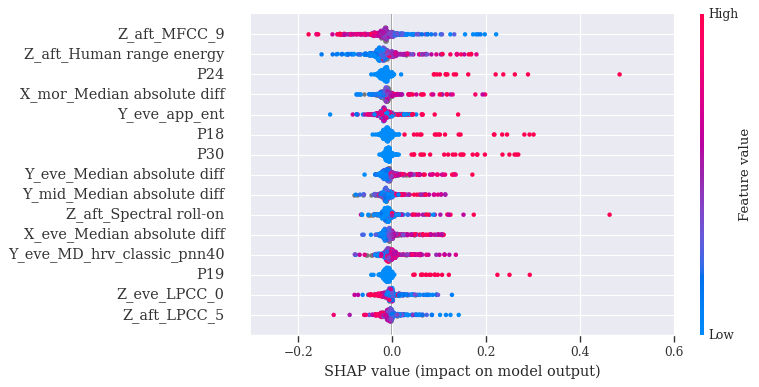

In [124]:
import matplotlib.pyplot
all_shap_values_concat = np.concatenate([sv for sv in all_shap_values])  # Use sv[1], sv[2], etc., for other classes

# Visualize SHAP values for all samples
shap.summary_plot(all_shap_values_concat, X_test_all, max_display=15, plot_size=[10,5], show=False)
matplotlib.pyplot.savefig("shap_euler_knn_nest_predict.pdf",dpi=700) #.png,.pdf will also support here


# Nested Cross-Validation k-NN + SMOTE

In [125]:
# Define a wrapper function for the pipeline's predict_proba method
def model_predict(X):
    return best_model.predict(X)

# Initialize lists to store SHAP values and corresponding feature values
all_shap_values = []
all_X_test = []
flag_test = 0

In [126]:
param_grid = [
    {
        'model__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
        'model__weights': ['uniform', 'distance'],
        'model__p': [1, 2, 3, 4, 5]
        
    }]


distributions_knn = dict(n_neighbors = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], weights = ['uniform', 'distance'], p = [1, 2, 3, 4, 5])

# Create the classifier
    

In [127]:
from sklearn import neighbors, datasets



model = neighbors.KNeighborsClassifier(n_neighbors=4, weights='uniform')




# Define pipeline with SMOTE
pipe = ImbPipeline([
    ('imp', SimpleImputer(missing_values=np.nan, strategy='mean')),
    ('over', SMOTE()),
    ('sca', StandardScaler()),  # Preprocessing step
    ('model', model)  # Model with probability=True
])



In [128]:
i= 0
# enumerate splits
y_true_all = []
y_pred_all = []
y_pred_proba_all = []
for train_ix, test_ix in cv.split(X_new2):
    # split data
    X_train0 = X_new2.loc[train_ix, :]
    y_train0 = y.loc[train_ix] 
    # configure the cross-validation procedure
    # configure the cross-validation procedure
    
    record = i
    #Read the extra data

    extra_AU = pd.read_csv('./dataset/euler_cross/eul_'+str(i)+'_.csv')
    
    if len(extra_AU)>1:
        subrecord = extra_AU['subrecord']

        type_data = extra_AU['type_data']

        #Create extra dummies files:
        data_dummies_extra = pd.DataFrame(columns=patients_pandas_encoded.columns)

        for subsample in range(0, len(extra_AU)):
            data_dummies_extra.loc[subsample] = [False]*len(patients_pandas_encoded.columns)
        data_dummies_extra[extra_AU['patient'].loc[0]] = True

        extra_AU2 = pd.concat([extra_AU[col], data_dummies_extra, extra_AU['subrecord'], extra_AU['type_data'], extra_AU['diagnosis']], axis=1)

        for sub_record in range(1, max(subrecord) +1):
            extra_AU3 = extra_AU2[extra_AU['subrecord']==sub_record]
            extra_test_AU = extra_AU3[extra_AU3['type_data']=='test']
            y_test = extra_test_AU['diagnosis']
            del extra_test_AU['subrecord']
            del extra_test_AU['type_data']
            del extra_test_AU['diagnosis']
            X_test = extra_test_AU 
            extra_train_AU = extra_AU3[extra_AU3['type_data']=='train']

            #Add extra train values
            if (len(extra_train_AU))>0:
                y_train = pd.concat([y_train0, extra_train_AU['diagnosis']], axis=0)
                del extra_train_AU['subrecord']
                del extra_train_AU['type_data']
                del extra_train_AU['diagnosis']
                X_train = pd.concat([X_train0, extra_train_AU], axis=0)
            else:
                X_train = X_train0
                y_train = y_train0

            #fill the Nan values



            columns_test = X_test.columns

            cv_inner = StratifiedKFold(n_splits=3, random_state=seed, shuffle=True)
            # define the model

            # define search
            search = GridSearchCV(pipe, param_grid, scoring='roc_auc', cv=cv_inner, refit=True)
            # execute search
            result = search.fit(X_train, y_train)
            # get the best performing model fit on the whole training set
            best_model = result.best_estimator_
            # evaluate model on the hold out dataset
            
            if flag_test==0:
                X_test = pd.DataFrame(X_test, columns=columns_test)
                X_test_all = X_test.copy()
                flag_test = 1
            else:
                X_test = pd.DataFrame(X_test, columns=columns_test)
                X_test_all = pd.concat([X_test_all, X_test], axis=0)
            
            
            explainer = shap.KernelExplainer(model_predict, X_train)
            #apply the preprocessing to x_test
            
            sv = explainer.shap_values(X_test)
            all_shap_values.append(sv)
  
            # Predict on the test data
            y_pred = best_model.predict(X_test)
            y_pred_proba = best_model.predict_proba(X_test)[:, 1]  # Probabilities for AUC

            # Collect predictions and true labels
            y_true_all.extend(y_test)
            y_pred_all.extend(y_pred)
            y_pred_proba_all.extend(y_pred_proba)
    
    print(i)
    i+=1

# Compute metrics
auc_score = roc_auc_score(y_true_all, y_pred_proba_all)
precision = precision_score(y_true_all, y_pred_all)
recall = recall_score(y_true_all, y_pred_all)
f1 = f1_score(y_true_all, y_pred_all)
acc = accuracy_score(y_true_all, y_pred_all)
balanced_acc = balanced_accuracy_score(y_true_all, y_pred_all)

print(f'AUC: {auc_score}, Precision: {precision}, Recall: {recall}, F1-score: {f1}, Accuracy: {acc}, Balanced Accuracy: {balanced_acc}')



  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

41


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

42
AUC: 0.9269815036219144, Precision: 0.8290598290598291, Recall: 0.8220338983050848, F1-score: 0.825531914893617, Accuracy: 0.8857938718662952, Balanced Accuracy: 0.8695231732189324


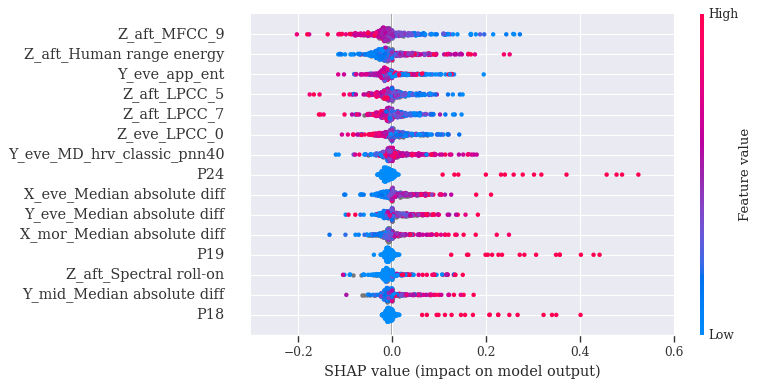

In [129]:
import matplotlib.pyplot
all_shap_values_concat = np.concatenate([sv for sv in all_shap_values])  # Use sv[1], sv[2], etc., for other classes

# Visualize SHAP values for all samples
shap.summary_plot(all_shap_values_concat, X_test_all, max_display=15, plot_size=[10,5], show=False)
matplotlib.pyplot.savefig("shap_euler_knn_smote_nest_predict.pdf",dpi=700) #.png,.pdf will also support here
